<a href="https://colab.research.google.com/github/BahadirKoksal/instacart-e-commerce/blob/main/notebooks/02_linear_regression/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd

# Google hesabı yetkilendirme
auth.authenticate_user()

# Project ID tanımlama
PROJECT_ID = "project-84485539-b01a-418a-932"
client = bigquery.Client(project=PROJECT_ID)
print("BigQuery bağlantısı başarılı!")

BigQuery bağlantısı başarılı!


In [15]:
query = """
SELECT *
FROM `project-84485539-b01a-418a-932.Instacart_Analytics.order_features_linreg`
"""

df = client.query(query).to_dataframe(create_bqstorage_client=False)
print(f"Satır sayısı: {len(df)}")
print(f"Kolon sayısı: {len(df.columns)}")
df.head()

Satır sayısı: 3346083
Kolon sayısı: 10


,order_id,user_id,item_count,order_dow,order_hour_of_day,days_since_prior_order,distinct_department_count,avg_days_between_orders,distinct_aisle_count,reorder_rate
0,2085530,95590,2,6,9,14.0,1,13.56,1,0.8000
1,1816820,88582,1,2,11,20.0,1,24.36,1,0.9333
2,1530686,172798,1,4,14,NaN,1,17.33,1,0.5000
3,1933529,196658,2,0,10,NaN,1,14.00,1,0.6000
4,1864355,22733,1,2,9,15.0,1,16.25,1,0.8519


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3346083 entries, 0 to 3346082
Data columns (total 10 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   order_id                   Int64  
 1   user_id                    Int64  
 2   item_count                 Int64  
 3   order_dow                  Int64  
 4   order_hour_of_day          Int64  
 5   days_since_prior_order     float64
 6   distinct_department_count  Int64  
 7   avg_days_between_orders    float64
 8   distinct_aisle_count       Int64  
 9   reorder_rate               float64
dtypes: Int64(7), float64(3)
memory usage: 277.6 MB


In [17]:
df.isnull().sum()

,0
order_id,0
user_id,0
item_count,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,206209
distinct_department_count,0
avg_days_between_orders,0
distinct_aisle_count,0
reorder_rate,0


In [18]:
df['is_first_order'] = df['days_since_prior_order'].isnull().astype(int)
df['days_since_prior_order'] = df['days_since_prior_order'].fillna(df['days_since_prior_order'].median())

In [19]:
df.isnull().sum()

,0
order_id,0
user_id,0
item_count,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,0
distinct_department_count,0
avg_days_between_orders,0
distinct_aisle_count,0
reorder_rate,0


In [20]:
df['item_count'].describe()

,item_count
count,3346083.0
mean,10.107073
std,7.542326
min,1.0
25%,5.0
50%,8.0
75%,14.0
max,145.0


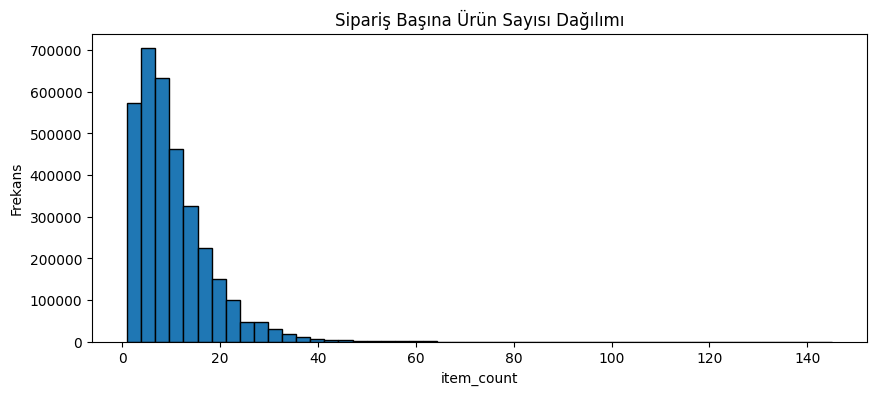

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(df['item_count'], bins=50, edgecolor='black')
plt.xlabel('item_count')
plt.ylabel('Frekans')
plt.title('Sipariş Başına Ürün Sayısı Dağılımı')
plt.show()

In [22]:
upper_limit = df['item_count'].quantile(0.99)
print(f"99. persentil sınırı: {upper_limit}")

df['item_count_capped'] = df['item_count'].clip(upper=upper_limit)

99. persentil sınırı: 35.0


In [23]:
df[['order_dow', 'order_hour_of_day', 'days_since_prior_order',
    'distinct_department_count', 'avg_days_between_orders',
    'distinct_aisle_count', 'reorder_rate']].describe()

,order_dow,order_hour_of_day,days_since_prior_order,distinct_department_count,avg_days_between_orders,distinct_aisle_count,reorder_rate
count,3346083.0,3346083.0,3.346083e+06,3346083.0,3.346083e+06,3346083.0,3.346083e+06
mean,2.776053,13.448873,1.072749e+01,4.74184,1.154886e+01,37.877649,5.768404e-01
std,2.044998,4.226137,8.887426e+00,2.552517,6.297368e+00,18.151156,1.943408e-01
min,0.0,0.0,0.000000e+00,1.0,0.000000e+00,1.0,0.000000e+00
25%,1.0,10.0,5.000000e+00,3.0,6.760000e+00,24.0,4.474000e-01
50%,3.0,13.0,7.000000e+00,4.0,1.004000e+01,37.0,6.058000e-01
75%,5.0,16.0,1.400000e+01,6.0,1.532000e+01,51.0,7.282000e-01
max,6.0,23.0,3.000000e+01,18.0,3.000000e+01,102.0,9.896000e-01


In [24]:
correlation_cols = ['item_count_capped', 'order_dow', 'order_hour_of_day',
                     'days_since_prior_order', 'distinct_department_count',
                     'avg_days_between_orders', 'distinct_aisle_count',
                     'reorder_rate', 'is_first_order']

df[correlation_cols].corr()['item_count_capped'].sort_values(ascending=False)

,item_count_capped
item_count_capped,1.000000
distinct_department_count,0.831077
distinct_aisle_count,0.411234
reorder_rate,0.091530
days_since_prior_order,0.055688
avg_days_between_orders,0.014451
is_first_order,-0.000836
order_hour_of_day,-0.005206
order_dow,-0.026275


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Kullanılacak bağımsız değişkenler (predictor'lar)
features = ['order_dow', 'order_hour_of_day', 'days_since_prior_order',
            'distinct_department_count', 'avg_days_between_orders',
            'distinct_aisle_count', 'reorder_rate', 'is_first_order']

target = 'item_count_capped'

X = df[features]
y = df[target]

# Train/test ayrımı (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

# Ölçekleme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Ölçekleme tamamlandı.")

Eğitim seti boyutu: (2676866, 8)
Test seti boyutu: (669217, 8)
Ölçekleme tamamlandı.


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Modeli kur ve eğit
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Test verisiyle tahmin yap
y_pred = model.predict(X_test_scaled)

# Performans metrikleri
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R² (açıklanan varyans oranı): {r2:.4f}")
print(f"RMSE (hata kök ortalama kare): {rmse:.4f}")
print(f"MAE (ortalama mutlak hata): {mae:.4f}")

R² (açıklanan varyans oranı): 0.6985
RMSE (hata kök ortalama kare): 3.9851
MAE (ortalama mutlak hata): 2.9188


In [27]:
coefficients = pd.DataFrame({
    'Değişken': features,
    'Katsayı': model.coef_
}).sort_values(by='Katsayı', ascending=False)

print(coefficients)
print(f"\nIntercept (sabit terim): {model.intercept_:.4f}")

                    Değişken   Katsayı
3  distinct_department_count  5.773505
6               reorder_rate  0.642709
5       distinct_aisle_count  0.452000
4    avg_days_between_orders  0.342045
2     days_since_prior_order  0.207437
7             is_first_order  0.117620
0                  order_dow -0.060598
1          order_hour_of_day -0.115441

Intercept (sabit terim): 10.0369


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


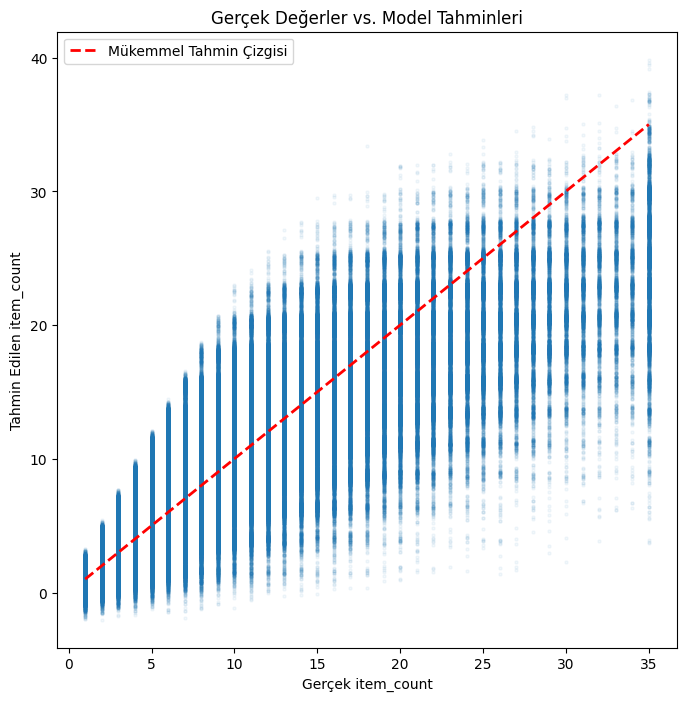

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.05, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Mükemmel Tahmin Çizgisi')
plt.xlabel('Gerçek item_count')
plt.ylabel('Tahmin Edilen item_count')
plt.title('Gerçek Değerler vs. Model Tahminleri')
plt.legend()
plt.show()

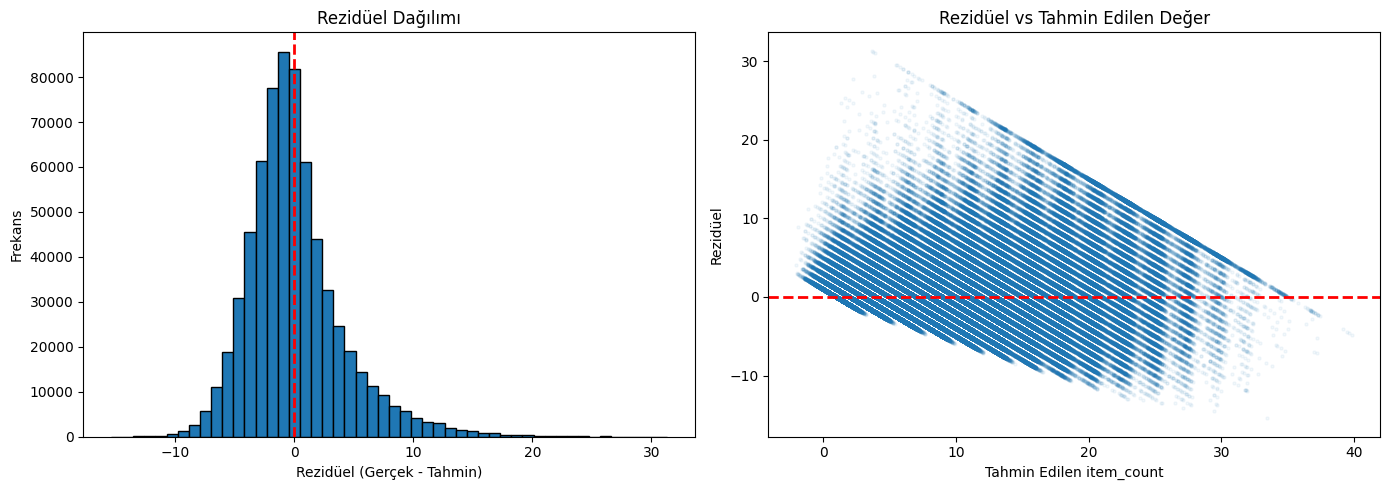

Rezidüel ortalaması: 0.0088
Rezidüel standart sapması: 3.9851


In [29]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Rezidüel dağılımı (histogram)
axes[0].hist(residuals, bins=50, edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Rezidüel (Gerçek - Tahmin)')
axes[0].set_ylabel('Frekans')
axes[0].set_title('Rezidüel Dağılımı')

# 2. Rezidüel vs Tahmin edilen değer
axes[1].scatter(y_pred, residuals, alpha=0.05, s=5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Tahmin Edilen item_count')
axes[1].set_ylabel('Rezidüel')
axes[1].set_title('Rezidüel vs Tahmin Edilen Değer')

plt.tight_layout()
plt.show()

print(f"Rezidüel ortalaması: {residuals.mean():.4f}")
print(f"Rezidüel standart sapması: {residuals.std():.4f}")

In [30]:
senaryolar = pd.DataFrame({
    'order_dow': [2, 5, 1],
    'order_hour_of_day': [14, 11, 20],
    'days_since_prior_order': [7, 3, 25],
    'distinct_department_count': [3, 8, 2],
    'avg_days_between_orders': [10, 5, 22],
    'distinct_aisle_count': [15, 45, 8],
    'reorder_rate': [0.3, 0.75, 0.15],
    'is_first_order': [0, 0, 1]
}, index=['Sıradan Müşteri', 'Sadık & Çeşitli Alışverişçi', 'Yeni/Nadir Müşteri (İlk Sipariş)'])

senaryolar_scaled = scaler.transform(senaryolar)
tahminler = model.predict(senaryolar_scaled)

sonuclar = senaryolar.copy()
sonuclar['Tahmin Edilen Sepet Büyüklüğü'] = tahminler.round(1)

print(sonuclar[['distinct_department_count', 'distinct_aisle_count', 'reorder_rate', 'Tahmin Edilen Sepet Büyüklüğü']])

                                  distinct_department_count  \
Sıradan Müşteri                                           3   
Sadık & Çeşitli Alışverişçi                               8   
Yeni/Nadir Müşteri (İlk Sipariş)                          2   

                                  distinct_aisle_count  reorder_rate  \
Sıradan Müşteri                                     15          0.30   
Sadık & Çeşitli Alışverişçi                         45          0.75   
Yeni/Nadir Müşteri (İlk Sipariş)                     8          0.15   

                                  Tahmin Edilen Sepet Büyüklüğü  
Sıradan Müşteri                                             4.4  
Sadık & Çeşitli Alışverişçi                                17.6  
Yeni/Nadir Müşteri (İlk Sipariş)                            2.9  


In [31]:
zamanlama_senaryolari = pd.DataFrame({
    'order_dow': [0, 3, 6],
    'order_hour_of_day': [3, 9, 22],
    'days_since_prior_order': [10, 10, 10],
    'distinct_department_count': [5, 5, 5],
    'avg_days_between_orders': [10, 10, 10],
    'distinct_aisle_count': [25, 25, 25],
    'reorder_rate': [0.5, 0.5, 0.5],
    'is_first_order': [0, 0, 0]
}, index=['Pazar Gecesi 03:00', 'Çarşamba Sabahı 09:00', 'Cumartesi Gecesi 22:00'])

zamanlama_scaled = scaler.transform(zamanlama_senaryolari)
zamanlama_tahminleri = model.predict(zamanlama_scaled)

zamanlama_sonuclar = zamanlama_senaryolari.copy()
zamanlama_sonuclar['Tahmin Edilen Sepet Büyüklüğü'] = zamanlama_tahminleri.round(2)

print(zamanlama_sonuclar[['order_dow', 'order_hour_of_day', 'Tahmin Edilen Sepet Büyüklüğü']])

                        order_dow  order_hour_of_day  \
Pazar Gecesi 03:00              0                  3   
Çarşamba Sabahı 09:00           3                  9   
Cumartesi Gecesi 22:00          6                 22   

                        Tahmin Edilen Sepet Büyüklüğü  
Pazar Gecesi 03:00                              10.28  
Çarşamba Sabahı 09:00                           10.03  
Cumartesi Gecesi 22:00                           9.59  
